## Learning Objectives

By the end of this notebook, students will build and evaluate several regression models:

* Simple Linear Regression using one numeric feature
* Multiple Linear Regression using several numeric features
* Linear Regression with Categorical Variables using encoded features
* Model comparison using MAE, RMSE, and R²

In [1]:
# imports
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set up path variables
RAW_DATA = Path("..") / "data" / "raw"

housing = pd.read_csv(RAW_DATA / "ames.csv")

housing.head()

,rownames,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,...,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,1,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,...,No_Fence,NaN,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,2,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,...,Minimum_Privacy,NaN,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,...,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,4,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,...,No_Fence,NaN,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,5,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,...,Minimum_Privacy,NaN,0,3,2010,WD,Normal,189900,-93.638933,42.060899


inspect our dataset

In [4]:
# .shape
housing.shape

(2930, 75)

In [5]:
# .info()
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 75 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rownames            2930 non-null   int64  
 1   MS_SubClass         2930 non-null   object 
 2   MS_Zoning           2930 non-null   object 
 3   Lot_Frontage        2930 non-null   int64  
 4   Lot_Area            2930 non-null   int64  
 5   Street              2930 non-null   object 
 6   Alley               2930 non-null   object 
 7   Lot_Shape           2930 non-null   object 
 8   Land_Contour        2930 non-null   object 
 9   Utilities           2930 non-null   object 
 10  Lot_Config          2930 non-null   object 
 11  Land_Slope          2930 non-null   object 
 12  Neighborhood        2930 non-null   object 
 13  Condition_1         2930 non-null   object 
 14  Condition_2         2930 non-null   object 
 15  Bldg_Type           2930 non-null   object 
 16  House_

In [6]:
housing.describe()

,rownames,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,...,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Year_Sold,Sale_Price,Longitude,Latitude
count,2930.00000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,57.647782,10147.921843,1971.356314,1984.266553,101.096928,4.177474,49.705461,559.071672,1051.255631,...,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068,-93.642897,42.034482
std,845.96247,33.499441,7880.017759,30.245361,20.860286,178.634545,2.233372,169.142089,439.540571,440.968018,...,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357,0.025700,0.018410
min,1.00000,0.000000,1300.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000,-93.693153,41.986498
25%,733.25000,43.000000,7440.250000,1954.000000,1965.000000,0.000000,3.000000,0.000000,219.000000,793.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000,-93.660217,42.022088
50%,1465.50000,63.000000,9436.500000,1973.000000,1993.000000,0.000000,3.000000,0.000000,465.500000,990.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000,-93.641806,42.034662
75%,2197.75000,78.000000,11555.250000,2001.000000,2004.000000,162.750000,7.000000,0.000000,801.750000,1301.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000,-93.622113,42.049853
max,2930.00000,313.000000,215245.000000,2010.000000,2010.000000,1600.000000,7.000000,1526.000000,2336.000000,6110.000000,...,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000,-93.577427,42.063388


In [10]:
# We're going to only grab a few columns for this module

housing = housing[['Sale_Price', 'Gr_Liv_Area', 'Overall_Cond', 'Garage_Cars', 'Neighborhood']].copy()

housing.head()

,Sale_Price,Gr_Liv_Area,Overall_Cond,Garage_Cars,Neighborhood
0,215000,1656,Average,2,North_Ames
1,105000,896,Above_Average,1,North_Ames
2,172000,1329,Above_Average,1,North_Ames
3,244000,2110,Average,2,North_Ames
4,189900,1629,Average,2,Gilbert


---

Some Quick EDA and Data cleaning

In [11]:
# Check for missing values
housing.isna().sum()

Sale_Price      0
Gr_Liv_Area     0
Overall_Cond    0
Garage_Cars     0
Neighborhood    0
dtype: int64

In [12]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Sale_Price    2930 non-null   int64 
 1   Gr_Liv_Area   2930 non-null   int64 
 2   Overall_Cond  2930 non-null   object
 3   Garage_Cars   2930 non-null   int64 
 4   Neighborhood  2930 non-null   object
dtypes: int64(3), object(2)
memory usage: 114.6+ KB


---

Our "target variable" is the variable we're trying to predict.

In this dataset, we're trying to predict the price of the home, `Sale_Price`.



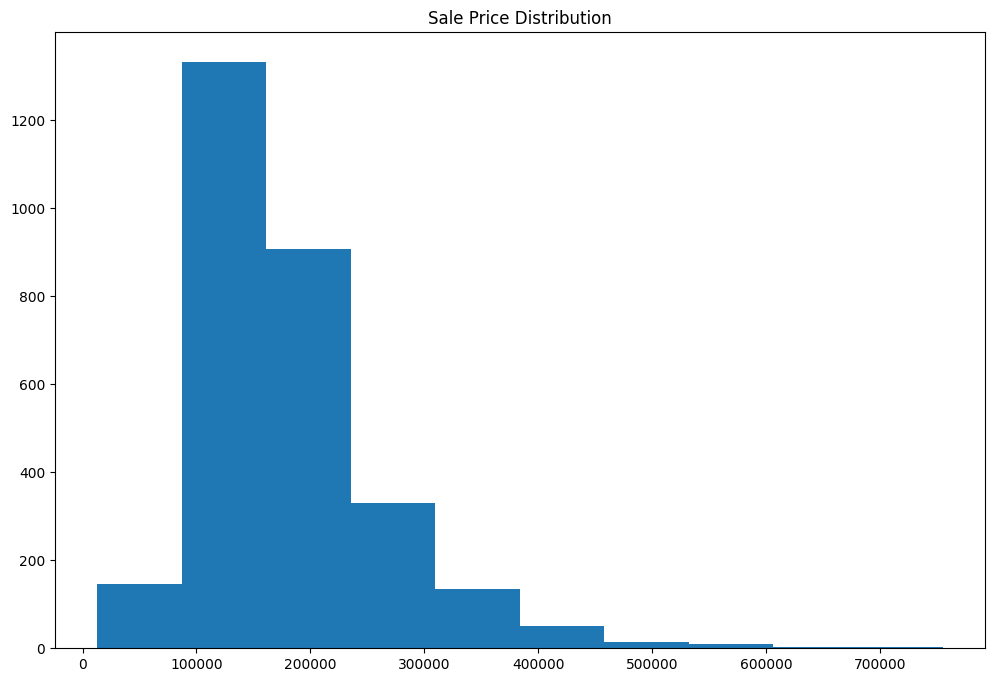

In [13]:
# Plot our Target Variable Distribution
plt.figure(figsize=(12, 8))
plt.hist(housing['Sale_Price'])
plt.title("Sale Price Distribution");

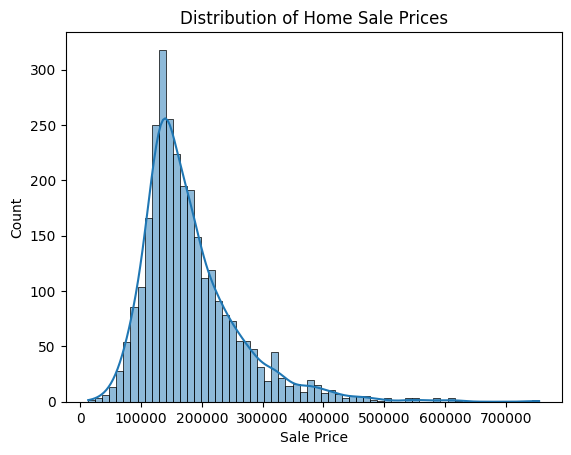

In [14]:
# little nicer with seaborn
sns.histplot(housing["Sale_Price"], kde=True)
plt.title("Distribution of Home Sale Prices")
plt.xlabel("Sale Price");

Before modeling, we should understand what our target variable looks like.

---

Let's start off with visualizing the relationship between Greater living area, `Gr_Liv_Area` and `Sale_Price`.

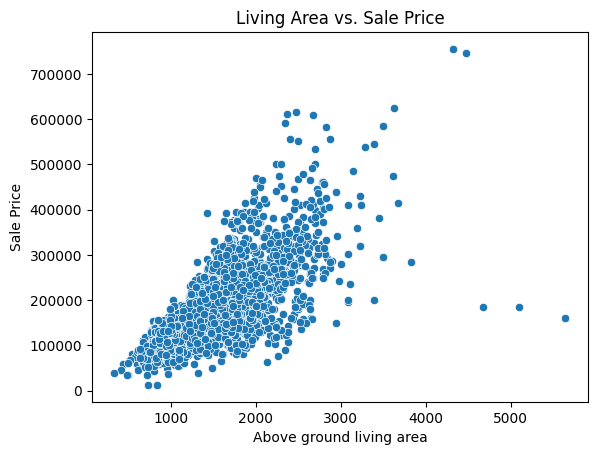

In [15]:
sns.scatterplot(data=housing,
               x="Gr_Liv_Area",
               y="Sale_Price")
plt.title("Living Area vs. Sale Price")
plt.xlabel("Above ground living area")
plt.ylabel("Sale Price");

Unsurprisingly, the larger a home, the more it sells for. 

It's not a perfect relationship, but it generally holds.

But what if we could quantify this relationship? If we increased the living area of a home, how does that affect sale prices?

---

We can do this with what's known as a "Linear Regression".

A linear regression is a linear model (think line). We're trying to draw a line that best fits the relationship between a feature and target variable.

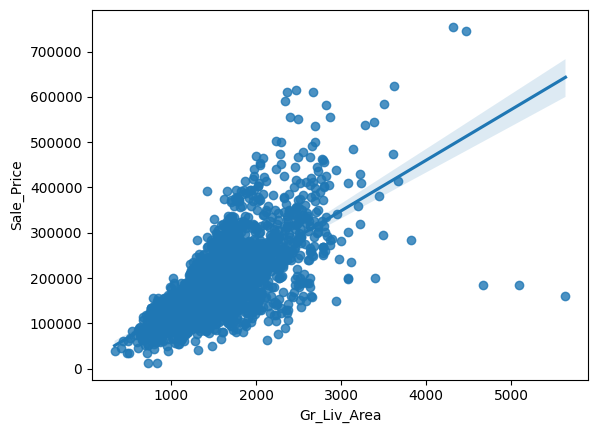

In [17]:
sns.regplot(data=housing,
           x='Gr_Liv_Area',
           y='Sale_Price');

That line in the regplot is what we're trying to find out!

---

Getting started with `sklearn`

In [18]:
# sklearn imports

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [19]:
# Set up our features and target variable

# Our X variable (feature matrix), note the double square brackets
X = housing[["Gr_Liv_Area"]]

# our target vector, y Note the single square brackets
y = housing["Sale_Price"]

type(X), type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

Sci-kit learn models expect a certain shape of the variables. If we don't specify the correct shape, then it will throw an error.

---

## Train Test Split

In order to evaluate a model, we must see how it performs on data it was not trained on.

We split our data into training and test sets.

* Training - Use it to train the model
* Test - Used to evaluate model's performance

In [20]:
# Do our train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # we are removing 20% of our observations to evaluate the model
    random_state=42, # so we have the same train test split each time
)

In [21]:
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (2344, 1)
Testing features shape: (586, 1)
Training target shape: (2344,)
Testing target shape: (586,)


---

Creating our first model and training it

In [22]:
# creating an instance of a LinearRegression object
lin_reg = LinearRegression()

In [24]:
# We "fit" our model on the training data.
lin_reg.fit(X_train, y_train)

LinearRegression()

In [26]:
# We make predictions with our Test set
y_pred = lin_reg.predict(X_test)

Why don't we use `y_test` inside `.predict()`?

Because we're trying to make predictions about `y` with what we learned from the training set!

We then take our predictions and compare it to the actual values of y in `y_test`.

The difference between our predictions (`y_pred`) and our actual values (`y_test`) are how we can evaluate how good or bad our model is.

---

## Evaluating our model

In the time series lesson, we briefly covered how to evaluate a model.

We're going to see some of those metrics again along with a new one, R-squared.

We need to import from `sklearn`'s `metrics` module.

In [27]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [30]:
# let's write a function to make it easier to reuse and evaluate other models.

def eval_reg(y_test, y_pred):
    return {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

In [31]:
eval_reg(y_test, y_pred)

{'MAE': 41365.511318494726,
 'RMSE': 61815.726690484196,
 'R2': 0.5233974153691153}

Interpretation of metrics:

* MAE: On average, how many dollars off are the predictions?
* RMSE: Similar to MAE, but larger errors are punished more heavily.
* R²: How much variation in home price does the model explain?

---

A Benefit of linear regression is that it in *interpretable*.

What does that mean?

We can say that if variable X increases by one unit, our model estimtes that our target varible y, changes by the corresponding amount.

We can do this by getting the model's coefficients.

In [32]:
lin_reg.coef_

array([106.72915508])

A Simple interpretation:

For each additional square foot of living area, the model estimates that sale price increases by about `<our coefficient>` dollars.

**Caveat**

This is not a proof of causation. It is the relationship learned by the model. For proof of causation, more assumptions need to be met and tested.

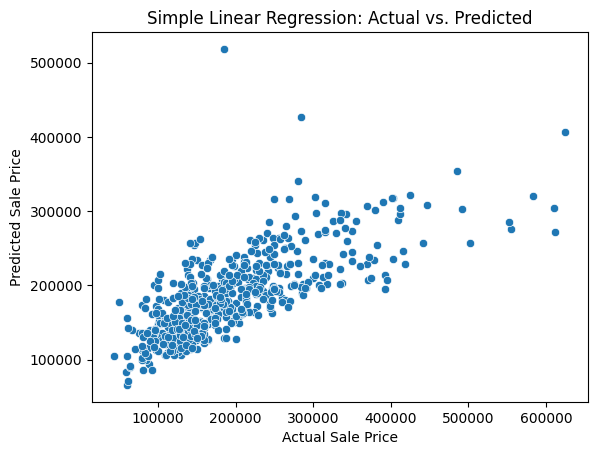

In [33]:
# Plot our predictions vs actual values
sns.scatterplot(x=y_test, y=y_pred)

plt.title("Simple Linear Regression: Actual vs. Predicted")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.show()

A stronger model would have points closer to a diagonal line.

---

## Multiple Linear Regression

We started with only using one feature in our regression model. 

However, we can add multiple features into our model!

Let's add another numeric feature.

In [36]:
numeric_features = [
    "Gr_Liv_Area",
    "Garage_Cars"
]

X = housing[numeric_features].copy()
y = housing['Sale_Price']

X.head()

,Gr_Liv_Area,Garage_Cars
0,1656,2
1,896,1
2,1329,1
3,2110,2
4,1629,2


In [37]:
# Check for any missing values
X.isna().sum()

Gr_Liv_Area    0
Garage_Cars    0
dtype: int64

In [38]:
# Split our Data Again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
# create a new instance of linear regression
multiple_lin_reg = LinearRegression()

# fit the model
multiple_lin_reg.fit(X_train, y_train)

# make preds
y_pred_multi = multiple_lin_reg.predict(X_test)

In [40]:
# evalute our model
eval_reg(y_test, y_pred_multi)

{'MAE': 35902.47123143017, 'RMSE': 54412.08402891452, 'R2': 0.6307256390752325}

In [46]:
# Can we still interpret our coefficients? Yes, but we a caveat
pd.Series(data=multiple_lin_reg.coef_, index=numeric_features)

Gr_Liv_Area       77.479482
Garage_Cars    41639.704671
dtype: float64

A coefficient tells us how the model uses a feature while holding the other features constant.

If we increased the number of cars the garage can fit, sale price would increase by $41,639 assuming greater living area **stays constant**

---

## Adding Categorical Variables

Linear models (and basically every other model in `sklearn`) cannot handle text data. We have to represent categories numerically so we can pass it through the model.

Let's look at `neighborhood`.

In [47]:
housing["Neighborhood"].value_counts()

Neighborhood
North_Ames                                 443
College_Creek                              267
Old_Town                                   239
Edwards                                    194
Somerset                                   182
Northridge_Heights                         166
Gilbert                                    165
Sawyer                                     151
Northwest_Ames                             131
Sawyer_West                                125
Mitchell                                   114
Brookside                                  108
Crawford                                   103
Iowa_DOT_and_Rail_Road                      93
Timberland                                  72
Northridge                                  71
Stone_Brook                                 51
South_and_West_of_Iowa_State_University     48
Clear_Creek                                 44
Meadow_Village                              37
Briardale                                   30


In [48]:
housing["Neighborhood"].nunique()

28

In [50]:
# set up our new feature matrix
numeric_cat_features = [
    "Gr_Liv_Area",
    "Garage_Cars",
    "Neighborhood"
]

X = housing[numeric_cat_features]
y = housing["Sale_Price"]

X.head()

,Gr_Liv_Area,Garage_Cars,Neighborhood
0,1656,2,North_Ames
1,896,1,North_Ames
2,1329,1,North_Ames
3,2110,2,North_Ames
4,1629,2,Gilbert


In [51]:
# Check for missing values... again
X.isna().sum()

Gr_Liv_Area     0
Garage_Cars     0
Neighborhood    0
dtype: int64

In [52]:
# What happens when we try to fit the model on our new X?
lin_reg = LinearRegression()

lin_reg.fit(X, y)

ValueError: could not convert string to float: 'North_Ames'

We get a `ValueError` because `sklearn` is trying to convert a string to a float and can't. 

---

`pd.get_dummies()` allows us to "dummify" a categorical varible. Let's walk through it.

In [54]:
pd.get_dummies(X["Neighborhood"], dtype=int)

,Bloomington_Heights,Blueste,Briardale,Brookside,Clear_Creek,College_Creek,Crawford,Edwards,Gilbert,Green_Hills,...,Northridge_Heights,Northwest_Ames,Old_Town,Sawyer,Sawyer_West,Somerset,South_and_West_of_Iowa_State_University,Stone_Brook,Timberland,Veenker
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2926,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2927,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2928,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


What is `pd.get_dummies()` doing?

It converts categorical variable into dummy/indicator variables.

Each variable is converted in as many 0/1 variables as there are different values. Columns in the output are each named after a value; if the input is a DataFrame, the name of the original variable is prepended to the value.

---

Let's encode our X variable

In [56]:
X_encoded = pd.get_dummies(
    X,
    columns=["Neighborhood"],
    drop_first=True,
    dtype=int
)

X_encoded.head()

,Gr_Liv_Area,Garage_Cars,Neighborhood_Blueste,Neighborhood_Briardale,Neighborhood_Brookside,Neighborhood_Clear_Creek,Neighborhood_College_Creek,Neighborhood_Crawford,Neighborhood_Edwards,Neighborhood_Gilbert,...,Neighborhood_Northridge_Heights,Neighborhood_Northwest_Ames,Neighborhood_Old_Town,Neighborhood_Sawyer,Neighborhood_Sawyer_West,Neighborhood_Somerset,Neighborhood_South_and_West_of_Iowa_State_University,Neighborhood_Stone_Brook,Neighborhood_Timberland,Neighborhood_Veenker
0,1656,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,896,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1329,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2110,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1629,2,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [57]:
# Do another train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [58]:
# Can we now call .fit()?

cat_lin_reg = LinearRegression()

In [59]:
# fit it
cat_lin_reg.fit(X_train, y_train)

LinearRegression()

In [60]:
y_pred_encoded = cat_lin_reg.predict(X_test)

In [61]:
eval_reg(y_test, y_pred_encoded)

{'MAE': 27876.43550746462, 'RMSE': 42823.25646010033, 'R2': 0.7712727994081483}